# Begin

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp
import sqlite3

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import DataLoader

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from dataset_utils import *
from utils import * # @launchit.collect
from logging_utils import *
from image_utils import *
from model_registry import *
from torch_helpers import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect
from hp_utils import *
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Init

In [3]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    model_group_uri=None,
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15d_predict_noncausal_02.ipynb',
 'self_name': '15d_predict_noncausal_02',
 'subproject_name': '15_transformer',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [4]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN_MODEL = auto()

class LaunchGoalObj(namedtuple('LaunchGoalObj', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')):
    def matches(self, *g):
        if CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK:
            return True
            
        if g and isinstance(g[0], list):
            assert len(g) == 1
            return self.goal in g[0]

        return self.goal in g

LAUNCH_GOAL = LaunchGoalObj(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=CONFIG.model_group_uri)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'model_name': '15d_predict_noncausal_02',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/15_transformer/15d_predict_noncausal_02.ipynb'}


# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    # dataset params
    db_fname: str = None
    # model params
    embedding_size: int = None
    layers_count: int = None
    heads_count: int = None
    # training params
    masking_levels: list = None # e.g., [0.25, 0.5, 0.75]
    batch_size: int = None
    epochs_count: int = None
    optimizer: str = None
    learn_rate: float | str = None
    test_batch_size: int = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

# Launch

## new_model_registry

In [6]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri)

## new_summary_writer

In [7]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [8]:
optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

model_registry = new_model_registry()
model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = LAUNCH_GOAL.model_name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
Tensorboard run=15d_predict_noncausal_02/0


<Mock name='mock.add_text()' id='134353345253296'>

# Dataset

## Configure

In [9]:
# @launchit.disable
# @launchit.collect
HP.db_fname = 'mini_dataset_5_128.db'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'db_fname': 'mini_dataset_5_128.db',
 'embedding_size': None,
 'layers_count': None,
 'heads_count': None,
 'masking_levels': None,
 'batch_size': None,
 'epochs_count': None,
 'optimizer': None,
 'learn_rate': None,
 'test_batch_size': None}


## get_db_con

In [10]:
def get_db_con(hp=None):
    hp = LangUtils.coalesce(hp, HP)
    assert hp.db_fname, f'Uninitialized {hp.db_fname=}'
    return sqlite3.connect(f'file:{os.path.join(CONFIG.private_data_path, hp.db_fname)}?mode=ro', uri=True)

## DataComponents

In [11]:
@dataclass
class DataComponents:
    meta: object = None
    images: dict = None
    test_images: dict = None
    vocab_token_ind_to_vocab_token: dict = None
    pos_token_ind_to_pos_token: dict = None
    df_samples: object = None
    df_test_samples: object = None
    pos_token_inds: object = None

    def get_image(self, image_ind, is_test):
        image_data = (self.images, self.test_images)[is_test][image_ind]
        return np.load(BytesIO(image_data))

DC = DataComponents()

## Load

In [12]:
with get_db_con() as db_con:
    DC.meta = load_meta(db_con)
    DC.images = dict(db_con.execute('SELECT image_ind, data FROM images').fetchall())
    DC.test_images = dict(db_con.execute('SELECT image_ind, data FROM test_images').fetchall())
    DC.vocab_token_ind_to_vocab_token = {}

    for vt in (load_vocab_tokens(db_con).itertuples()):
        if vt.data is not None:
            vt = vt._replace(data=np.load(BytesIO(vt.data)))

        DC.vocab_token_ind_to_vocab_token[vt.Index] = vt

    DC.pos_token_ind_to_pos_token = dict(map(lambda t: (t.Index, t), load_pos_tokens(db_con).itertuples()))
    
    for attr_name, table_name in zip(('df_samples', 'df_test_samples'), ('noncausal_samples', 'test_noncausal_samples')):
        setattr(DC, attr_name, pd.read_sql(f'SELECT image_ind, vocab_token_inds, pos_token_inds, p_matrix FROM {table_name}', con=db_con))
        df = getattr(DC, attr_name)
        df.vocab_token_inds = df.vocab_token_inds.map(lambda i: np.array(list(map(int, i.split(',')))))
        df.pos_token_inds = df.pos_token_inds.map(lambda i: np.array(list(map(int, i.split(',')))))
        df.p_matrix = df.p_matrix.map(lambda m: np.load(BytesIO(m)))

    # Make sure all samples (both train and test) have the same positional tokens
    DC.pos_token_inds = None

    for df in (DC.df_samples, DC.df_test_samples):
        for sample in df.itertuples():
            if DC.pos_token_inds is None:
                DC.pos_token_inds = sample.pos_token_inds
            else:
                assert np.all(DC.pos_token_inds == sample.pos_token_inds), image_ind
        
        df.drop('pos_token_inds', axis=1, inplace=True)

# Model

## NoncausalModel

In [13]:
class NoncausalModel(nn.Module):
    PAD_TOKEN_IND = 0
    MASK_TOKEN_IND = 1
    
    def __init__(self, vocab_size, pos_tokens_count, hp):
        super().__init__()
        self.vocab_embedding = nn.Embedding(vocab_size, hp.embedding_size)
        self.pos_embedding = nn.Embedding(pos_tokens_count, hp.embedding_size)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hp.embedding_size, 
            nhead=hp.heads_count, 
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=hp.layers_count)
        self.fc_out = nn.Linear(hp.embedding_size, vocab_size)

    def forward(self, vocab_token_inds, pos_token_inds):
        x = self.vocab_embedding(vocab_token_inds)
        x = x + self.pos_embedding(pos_token_inds)
        output = self.encoder(x, is_causal=False)
        return self.fc_out(output)

## Test

In [14]:
# @launchit.disable
hp = Hyperparameters(embedding_size=256+128, heads_count=16, layers_count=4)
model = NoncausalModel(128, 576, hp)
print(model)
params_count = sum(p.numel() for p in model.parameters())
print(f'{params_count=:_}')
probe_batch = torch.tensor([[1,2,3,4,5], [5,4,3,2,1]])
print(f'{probe_batch.shape=}')
r = model(probe_batch, torch.arange(probe_batch.shape[1]))
print(f'{r.shape=}')

NoncausalModel(
  (vocab_embedding): Embedding(128, 384)
  (pos_embedding): Embedding(576, 384)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (linear1): Linear(in_features=384, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=384, bias=True)
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=384, out_features=128, bias=True)
)
params_count=8_992_384
probe_batch.shape=torch.Size([2, 5])
r.shape=torch.Size([2, 5, 128])


# Train utils

## generate_masks

In [15]:
def generate_masks(l, masking_steps):
    masks = np.zeros((len(masking_steps), l), dtype=bool)
    prev_masked_count = None
    free_inds = list(range(l))
    
    for i, masked_percentage in enumerate(masking_steps):
        masked_count = int(masked_percentage * l)
        assert 0 <= masked_count <= l, masked_count
        prev_masked_count = LangUtils.coalesce(prev_masked_count, 0)
        assert prev_masked_count <= masked_count, (prev_masked_count, masked_count, masked_percentage)
        items_to_mask = masked_count - prev_masked_count
        prev_masked_count = masked_count

        if items_to_mask == 0:
            continue

        assert items_to_mask <= len(free_inds), (len(free_inds), items_to_mask, masked_percentage)

        inds_for_masking = RNG.choice(free_inds, items_to_mask, replace=False)

        if i > 0:
            masks[i][:] = masks[i-1]
            
        masks[i,inds_for_masking] = True
        free_inds = list(set(free_inds) - set(inds_for_masking))

    return masks

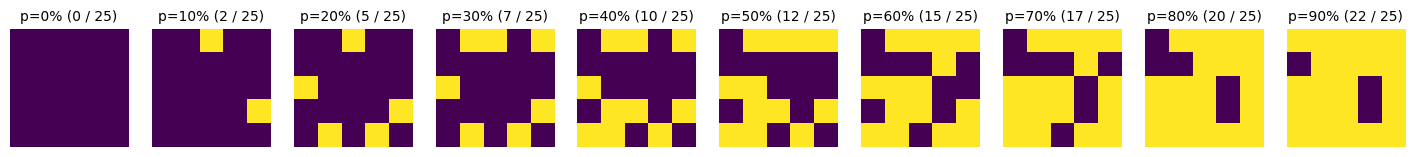

In [16]:
# @launchit.disable
masking_steps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
masks = generate_masks(25, masking_steps)
fig, axes = plt.subplots(1, len(masks))
fig.set_figwidth(18)

for mask, ax, mp in zip(masks, axes, masking_steps):
    ax.set_title(f'p={mp*100:.0f}% ({mask.sum()} / {len(mask)})', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(mask))
    ax.set_axis_off()

## collate_samples_to_batch

In [17]:
Batch = namedtuple('Batch', 'vocab_token_inds masks targets')

def collate_samples_to_batch(df_samples, masks, mask_value, device=None):
    origin_batch = np.vstack(df_samples.vocab_token_inds)
    p = einops.rearrange(np.vstack(df_samples.p_matrix), '(b s) d -> b s d', b=len(df_samples))
    assert masks.shape[1] == origin_batch.shape[1], (masks.shape[1], origin_batch.shape[1])
    masked_batches = []

    for mask in masks:
        masked_batch = origin_batch.copy()
        masked_batch[np.arange(len(masked_batch)),np.argwhere(mask)] = mask_value
        masked_batches.append(masked_batch)

    to_tensor = lambda a: torch.tensor(a).to(device=LangUtils.coalesce(device, CONFIG.cuda_device))
    return Batch(
        vocab_token_inds=to_tensor(np.array(masked_batches)),
        masks=to_tensor(einops.rearrange(np.repeat(masks, len(df_samples), axis=0), '(m b) v -> m b v', b=len(df_samples))), 
        targets=to_tensor(np.tile(p, (len(masks),1,1,1))),
    )

In [18]:
# @launchit.disable
%time
sample_indices = RNG.choice(DC.df_samples.index, 2, replace=False)
df_samples = DC.df_samples.loc[sample_indices]
masks = generate_masks(len(df_samples.iloc[0].vocab_token_inds), [0.25, 0.5, 0.75])
batch = collate_samples_to_batch(df_samples, masks, mask_value=-1)
print(batch.vocab_token_inds.shape, batch.masks.shape, batch.targets.shape)
assert batch.vocab_token_inds.shape == batch.masks.shape
assert batch.vocab_token_inds.shape == batch.targets.shape[:-1]

for i in range(batch.vocab_token_inds.shape[0]):
    for j in range(batch.vocab_token_inds.shape[1]):
        v_vec = batch.vocab_token_inds[i,j]
        m_vec = batch.masks[i,j]
        # Ensure masked values (-1) and boolean masks correspond each other (vocab_token_inds vs masks)
        assert torch.all(torch.where(v_vec == -1, True, False) == m_vec)
        t_mat = batch.targets[i,j]
        t_vec = torch.argmax(t_mat, axis=-1)
        t_vec = torch.tensor(list(map(lambda x: DC.vocab_token_ind_to_vocab_token[x.item()].Index, t_vec)))
        # Ensure nonmasked values and targets correspond each other (vocab_token_inds vs targets)
        assert torch.all(v_vec[~m_vec] == t_vec[~m_vec])

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 4.05 μs
torch.Size([3, 2, 25]) torch.Size([3, 2, 25]) torch.Size([3, 2, 25, 131])


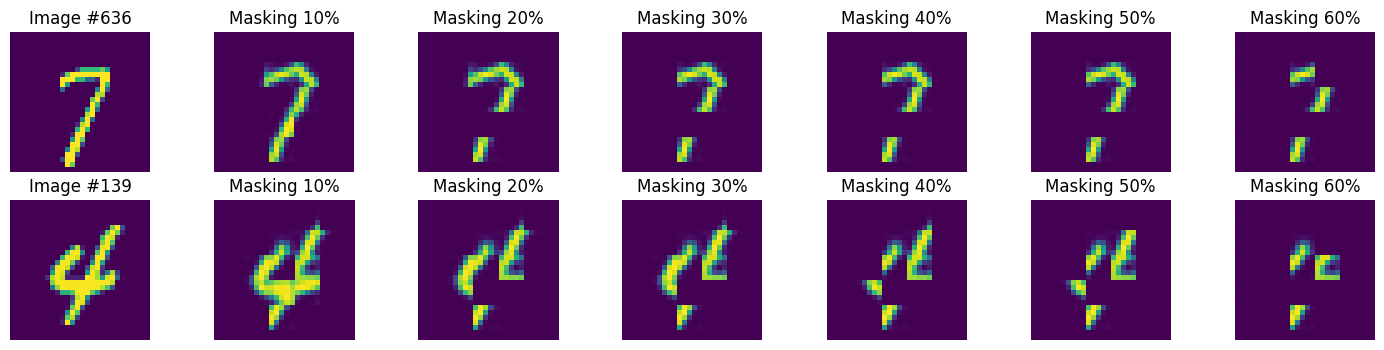

In [20]:
# @launchit.disable
sample_indices = RNG.choice(DC.df_samples.index, 2, replace=False)
df_samples = DC.df_samples.loc[sample_indices]
masking_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
masks = generate_masks(len(df_samples.iloc[0].vocab_token_inds), masking_levels)
batch = collate_samples_to_batch(df_samples, masks, mask_value=-1)
fig, axes = plt.subplots(len(sample_indices), len(masks) + 1)
fig.set_figwidth(18)
fig.set_figheight(2 * len(axes))

for j, (sample_row, ax_row) in enumerate(zip(df_samples.itertuples(), axes)):
    image = DC.get_image(sample_row.image_ind, is_test=False)
    ax_row[0].set_title(f'Image #{sample_row.image_ind}')
    ax_row[0].imshow(image)
    ax_row[0].set_axis_off()

    for i, (ml, ax) in enumerate(zip(masking_levels, ax_row[1:])):
        image_hat = np.zeros_like(image)

        for vocab_token_ind, pos_token_ind in zip(batch.vocab_token_inds[i,j], DC.pos_token_inds):
            if vocab_token_ind == -1:
                continue

            pt = DC.pos_token_ind_to_pos_token[pos_token_ind]
            vt = DC.vocab_token_ind_to_vocab_token[vocab_token_ind.item()]
            image_hat[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vt.data)

        ax.set_title(f'Masking {ml*100:.0f}%')
        ax.imshow(image_hat)
        ax.set_axis_off()

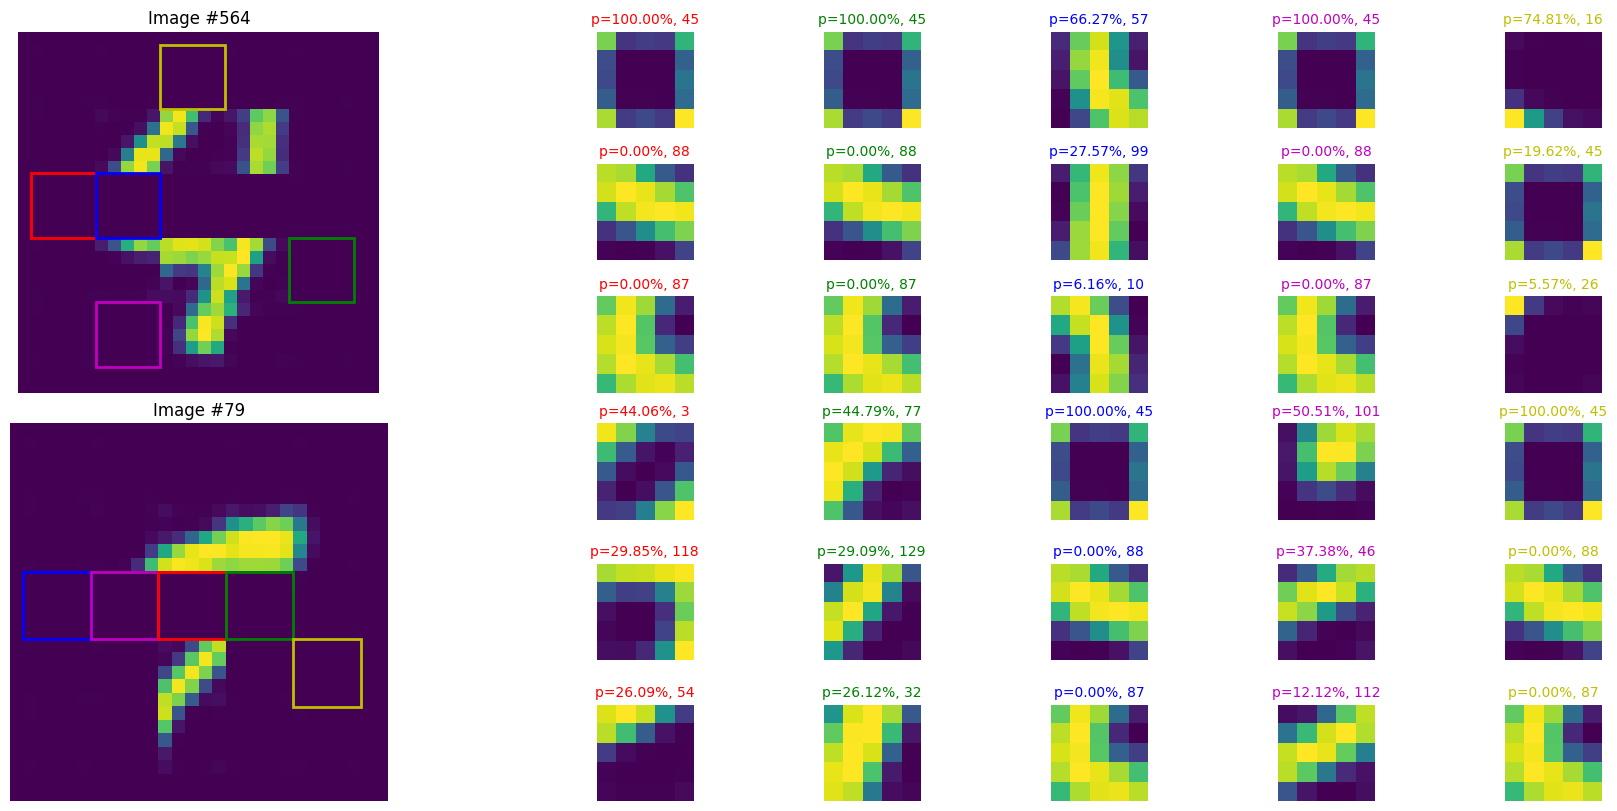

In [21]:
# @launchit.disable
sample_indices = RNG.choice(DC.df_samples.index, 2, replace=False)
df_samples = DC.df_samples.loc[sample_indices]
masking_levels = [0.3]
masks = generate_masks(len(df_samples.iloc[0].vocab_token_inds), masking_levels)
batch = collate_samples_to_batch(df_samples, masks, mask_value=-1)
fig, axd = plt.subplot_mosaic(
    [
        ['A', 'A', 'A', 'AM11', 'AM21', 'AM31', 'AM41', 'AM51'],
        ['A', 'A', 'A', 'AM12', 'AM22', 'AM32', 'AM42', 'AM52'],
        ['A', 'A', 'A', 'AM13', 'AM23', 'AM33', 'AM43', 'AM53'],
        ['B', 'B', 'B', 'BM11', 'BM21', 'BM31', 'BM41', 'BM51'],
        ['B', 'B', 'B', 'BM12', 'BM22', 'BM32', 'BM42', 'BM52'],
        ['B', 'B', 'B', 'BM13', 'BM23', 'BM33', 'BM43', 'BM53'],
    ], 
    layout="constrained"
)

fig.set_figwidth(18)
fig.set_figheight(4 * len(axes))

for i, (sample_row, ax_name) in enumerate(zip(df_samples.itertuples(), 'AB')):
    image_hat = np.zeros((DC.meta.image_size, DC.meta.image_size))
    masked_pos_token_inds = DC.pos_token_inds[batch.masks[0,i]]
    displayed_masked_pos_token_inds = dict(map(lambda x: (int(x[1]), x[0]), enumerate(RNG.choice(masked_pos_token_inds, 5, replace=False))))

    for j, (vocab_token_ind, pos_token_ind) in enumerate(zip(batch.vocab_token_inds[0,i], DC.pos_token_inds)):
        pt = DC.pos_token_ind_to_pos_token[pos_token_ind]
        
        if vocab_token_ind == -1:
            if pos_token_ind in displayed_masked_pos_token_inds:
                j2 = displayed_masked_pos_token_inds[pos_token_ind]
                color = 'rgbmy'[j2 % 5]
                rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), DC.meta.patch_size, DC.meta.patch_size, linewidth=2, edgecolor=color, facecolor='none')
                axd[ax_name].add_patch(rect)
                
                probs = batch.targets[0,i,j]
                top_probs = torch.topk(probs, 3)

                for k, (top_prob, top_index) in enumerate(zip(top_probs.values, top_probs.indices)):
                    axm_name = f'{ax_name}M{j2+1}{k+1}'
                    vt = DC.vocab_token_ind_to_vocab_token[top_index.item()]
                    axd[axm_name].set_title(f'p={top_prob*100:.2f}%, {vt.Index}', fontdict=dict(fontsize=10, color=color))
                    axd[axm_name].imshow(ArrayUtils.v2sm(vt.data))
                    axd[axm_name].set_axis_off()
        else:
            vt = DC.vocab_token_ind_to_vocab_token[vocab_token_ind.item()]
            image_hat[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vt.data)

    axd[ax_name].set_title(f'Image #{sample_row.image_ind}')
    axd[ax_name].imshow(image_hat)
    axd[ax_name].set_axis_off()

## visualize_predictions

In [22]:
def visualize_predictions(model, df_samples, masking_levels, masks, is_test, device=None):
    batch = collate_samples_to_batch(df_samples, masks, mask_value=NoncausalModel.MASK_TOKEN_IND, device=device)
    batch_shape = einops.parse_shape(batch.vocab_token_inds, 'm b s')
    
    with eval_guard(model):
        with torch.no_grad(): 
            logits = model(einops.rearrange(batch.vocab_token_inds, 'm b s -> (m b) s'), torch.tensor(DC.pos_token_inds)).detach().cpu().numpy()
            logits = einops.rearrange(logits, '(m b) s l -> m b s l', b=batch_shape['b'])
            predictions = np.argmax(logits, axis=-1)
    
    def generate_mosaic(samples_count, masking_levels_count):
        mosaic = []
        row = []
    
        for i in range(samples_count):
            row.extend([chr(ord('A') + i)] * 2)
    
        mosaic.append(row)
            
        for j in range(masking_levels_count):
            row = []
            
            for i in range(samples_count):
                prefix = chr(ord('A') + i)
                row.extend([f'{prefix}{j+1}1', f'{prefix}{j+1}2'])
            
            mosaic.append(row)
    
        return mosaic, ''.join(map(chr, ord('A') + np.arange(samples_count)))
    
    mosaic, major_letters = generate_mosaic(len(df_samples), len(masking_levels))
    fig, axd = plt.subplot_mosaic(mosaic, layout="constrained")
    fig.set_figwidth(16)
    fig.set_figheight(2 * len(mosaic))
    
    # Original image
    for sample_row, ax_name in zip(df_samples.itertuples(), major_letters):
        image = DC.get_image(sample_row.image_ind, is_test=is_test)
        axd[ax_name].set_title(f'{LangUtils.when(is_test, 'Test image', 'Image')} #{sample_row.image_ind}')
        axd[ax_name].imshow(image)
        axd[ax_name].set_axis_off()
    
    # Masked image
    for i in range(len(batch.vocab_token_inds)):
        for j, ax_name_prefix in zip(range(len(batch.vocab_token_inds[i])), major_letters):
            assert len(batch.vocab_token_inds[i,j]) == len(DC.pos_token_inds)
            image_hat = np.zeros((DC.meta.image_size, DC.meta.image_size))
            ax = axd[f'{ax_name_prefix}{i+1}1']
            
            for vocab_token_ind, pos_token_ind in zip(batch.vocab_token_inds[i,j], DC.pos_token_inds):
                vt = DC.vocab_token_ind_to_vocab_token[vocab_token_ind.item()]
                pt = DC.pos_token_ind_to_pos_token[pos_token_ind.item()]
    
                if vocab_token_ind.item() == NoncausalModel.MASK_TOKEN_IND:
                    rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), DC.meta.patch_size, DC.meta.patch_size, linewidth=1, edgecolor='w', facecolor='none')
                    ax.add_patch(rect)
                else:
                    image_hat[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vt.data)
    
            ax.set_title(f'Masking level={masking_levels[i]*100:.0f}%', fontdict=dict(fontsize=10))
            ax.imshow(image_hat)
            ax.set_axis_off()
    
    # Maked image with filled in items
    for i in range(len(predictions)):
        for j, ax_name_prefix in zip(range(len(predictions[i])), major_letters):
            assert len(predictions[i,j]) == len(DC.pos_token_inds)
            assert len(predictions[i,j]) == len(batch.vocab_token_inds[i,j])
            assert len(predictions[i,j]) == len(batch.masks[i,j])
            image_hat = np.zeros((DC.meta.image_size, DC.meta.image_size))
            ax = axd[f'{ax_name_prefix}{i+1}2']
            
            for k in range(len(predictions[i,j])):
                pt = DC.pos_token_ind_to_pos_token[DC.pos_token_inds[k]]
                mask_value = batch.masks[i,j,k].item()
                
                if mask_value:
                    # masked value - get from model's output (prediction)
                    vt = DC.vocab_token_ind_to_vocab_token[predictions[i,j,k]]
                    color = LangUtils.when(batch.targets[i,j,k,vt.Index] > 0.01, 'g', 'r')
                    lw = LangUtils.when(batch.targets[i,j,k,vt.Index] > 0.01, 2, 1)
                    rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), DC.meta.patch_size, DC.meta.patch_size, linewidth=lw, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                else:
                    # unmasked value - get from model's input
                    vt = DC.vocab_token_ind_to_vocab_token[batch.vocab_token_inds[i,j,k].item()]
                    
    
                if vt.data is not None:
                    image_hat[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vt.data)
    
            ax.set_title(f'Masking level={masking_levels[i]*100:.0f}%', fontdict=dict(fontsize=10))
            ax.imshow(image_hat)
            ax.set_axis_off()

    return fig

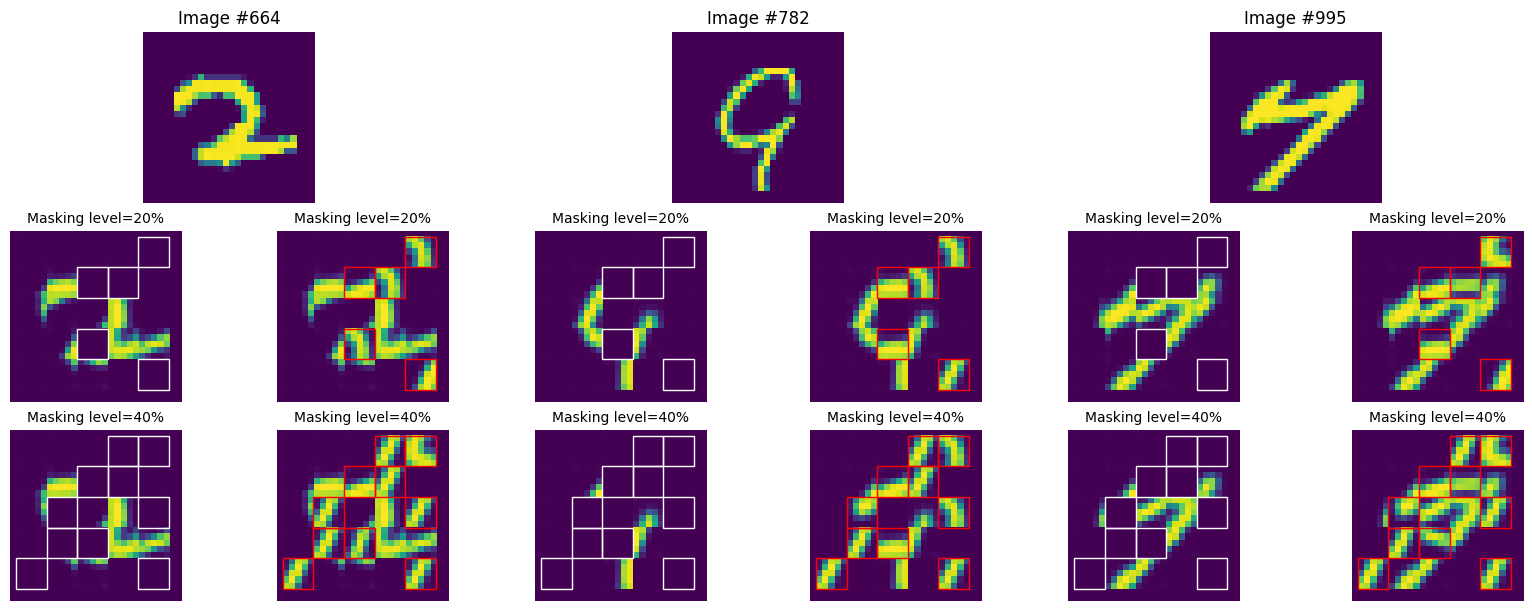

In [23]:
# @launchit.disable
hp = Hyperparameters(embedding_size=256+128, heads_count=16, layers_count=4)
model = NoncausalModel(len(DC.vocab_token_ind_to_vocab_token), len(DC.pos_token_ind_to_pos_token), hp)
samples_indices = RNG.choice(DC.df_samples.index, 3, replace=False)
df_samples = DC.df_samples.loc[samples_indices]
masking_levels = [0.2, 0.4]
masks = generate_masks(len(df_samples.iloc[0].vocab_token_inds), masking_levels)
fig = visualize_predictions(model, df_samples, masking_levels, masks, is_test=False)

# TRAIN_MODEL

## Configure

In [24]:
# @launchit.disable
# @launchit.collect
HP.embedding_size = 384
HP.layers_count = 6
HP.heads_count = 16
HP.masking_levels = [0.2, 0.4]
HP.batch_size = 100
HP.epochs_count = 1
HP.optimizer = 'Adam'
HP.learn_rate = '0.0001'
HP.test_batch_size = 1000
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'db_fname': 'mini_dataset_5_128.db',
 'embedding_size': 384,
 'layers_count': 6,
 'heads_count': 16,
 'masking_levels': [0.2, 0.4],
 'batch_size': 100,
 'epochs_count': 1,
 'optimizer': 'Adam',
 'learn_rate': '0.0001',
 'test_batch_size': 1000}


## Create

In [25]:
model = NoncausalModel(len(DC.vocab_token_ind_to_vocab_token), len(DC.pos_token_ind_to_pos_token), HP)
model = model.to(CONFIG.cuda_device)
data_loader = DataLoader(DC.df_samples.index, batch_size=HP.batch_size, shuffle=True)
lr_params = hp_parse_learn_rate(HP.learn_rate)
optimizer = getattr(torch.optim, HP.optimizer)(model.parameters(), lr=lr_params.learn_rate)
lr_scheduler = LrSchedulerWrapper(optimizer, lr_params)

## Train

In [56]:
only_pos_token_inds = torch.tensor(DC.pos_token_inds).to(CONFIG.cuda_device)

for epoch in tqdm(range(HP.epochs_count + 1), desc='Epoch', disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('EPOCH', epoch):
        epoch_loss = dict(all=0, ce=0)
        epoch_loss_denom = 0
    
        for sample_indices in tqdm(data_loader, leave=False, desc='Batch', disable=not CONFIG.is_interactive):
            optimizer.zero_grad()

            df_samples = DC.df_samples.loc[sample_indices]
            masks = generate_masks(len(df_samples.iloc[0].vocab_token_inds), HP.masking_levels)
            batch = collate_samples_to_batch(df_samples, masks, mask_value=NoncausalModel.MASK_TOKEN_IND, device=CONFIG.cuda_device)
            batch_shape = einops.parse_shape(batch.vocab_token_inds, 'm b s')
            logits = model(einops.rearrange(batch.vocab_token_inds, 'm b s -> (m b) s'), only_pos_token_inds)
            # Turn logits and targets to just matrices where each row is a logits/probability vector
            logits = einops.rearrange(logits, 'mb s l -> (mb s) l')
            targets = einops.rearrange(batch.targets, 'm b s l -> (m b s) l')
            # Use masks to select subset of rows which model should predict
            masks = einops.rearrange(batch.masks, 'm b s -> (m b s)')
            ce_loss = F.cross_entropy(logits[masks], targets[masks])
            loss = ce_loss

            if epoch > 0: # first run is a dry run to get losses baseline
                loss.backward()
                optimizer.step()

            for k, l in zip(('all', 'ce'), (loss, ce_loss)):
                epoch_loss[k] += l.item() * len(batch)
                
            epoch_loss_denom += len(batch)

        for k in epoch_loss:
            epoch_loss[k] = epoch_loss[k] / epoch_loss_denom
            
        lr_scheduler.step(epoch_loss['all'])
    
        assert epoch_loss_denom > 0

        # Report metrics and upload figures
        concat_log = []
        
        for k, l in epoch_loss.items():
            k = f'loss_{k}'
            summary_writer.add_scalar(k, l, epoch)
            METRICS_SUITE[k].append(l)
            concat_log.append(f'{k}={l:.4g}')

        with eval_guard(model):
            with torch.no_grad(): 
                if epoch == 0:
                    df_test_samples = LangUtils.when(HP.test_batch_size is not None, DC.df_test_samples.sample(HP.test_batch_size), DC.df_test_samples)
                    test_masks = generate_masks(len(df_test_samples.iloc[0].vocab_token_inds), HP.masking_levels)
                    test_batch = collate_samples_to_batch(df_test_samples, test_masks, mask_value=NoncausalModel.MASK_TOKEN_IND, device=CONFIG.cuda_device)
                    test_vocab_token_inds = einops.rearrange(test_batch.vocab_token_inds, 'm b s -> (m b) s')
                    test_targets = einops.rearrange(test_batch.targets, 'm b s l -> (m b s) l')
                    test_masks = einops.rearrange(test_batch.masks, 'm b s -> (m b s)')
                    
                test_logits = model(test_vocab_token_inds, only_pos_token_inds)
                test_logits = einops.rearrange(test_logits, 'mb s l -> (mb s) l')
                test_ce_loss = F.cross_entropy(test_logits[test_masks], test_targets[test_masks])
                k = 'test_loss_ce'
                summary_writer.add_scalar(k, test_ce_loss, epoch)
                METRICS_SUITE[k].append(test_ce_loss)
                concat_log.append(f'{k}={test_ce_loss:.4g}')
            
        LOG(', '.join(concat_log), when=not CONFIG.is_interactive)

        if optuna_trial is not None:
            # https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.report:
            # > If this method is called multiple times at the same step in a trial, the reported value only the first time is stored 
            # > and the reported values from the second time are ignored.
            # In other words calling report for fold other than the first one does nothing except producing tons of warnings in console. 
            # As such only the first fold is indicative
            optuna_trial.report(epoch_loss['all'], epoch) 
    
            if optuna_trial.should_prune():
                # Despite written in docs OPTUNA_TRIAL.should_prune is not idempotent - consequent calls could lead
                # to different responses. Perhapse this is due to influence of concurrent trials running which could change
                # pruner decision. As such cache pruning result so it's immutable
                optuna_trial.set_user_attr('IS_PRUNED', True)
                LOG(f'Optuna pruning condition encountered. Stopping training')
                break
    
        if (epoch % 20) == 0 or (epoch == HP.epochs_count):
            if epoch == 0:
                df_example_samples = DC.df_test_samples.sample(3)
                example_masks = generate_masks(len(df_example_samples.iloc[0].vocab_token_inds), HP.masking_levels)

            fig = visualize_predictions(model, df_example_samples, HP.masking_levels, example_masks, is_test=True, device=CONFIG.cuda_device)
            summary_writer.add_figure(f'predictions', fig, epoch, close=False) 
            plt.close(fig) # manual closing because summar_writer may be in Mock mode leaving fig unclosed
            LOG('Figure "predictions" uploaded', when=not CONFIG.is_interactive)
            
        summary_writer.flush()

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Batch:   0%|          | 0/10 [00:00<?, ?it/s]

Batch:   0%|          | 0/10 [00:00<?, ?it/s]

## Visualize

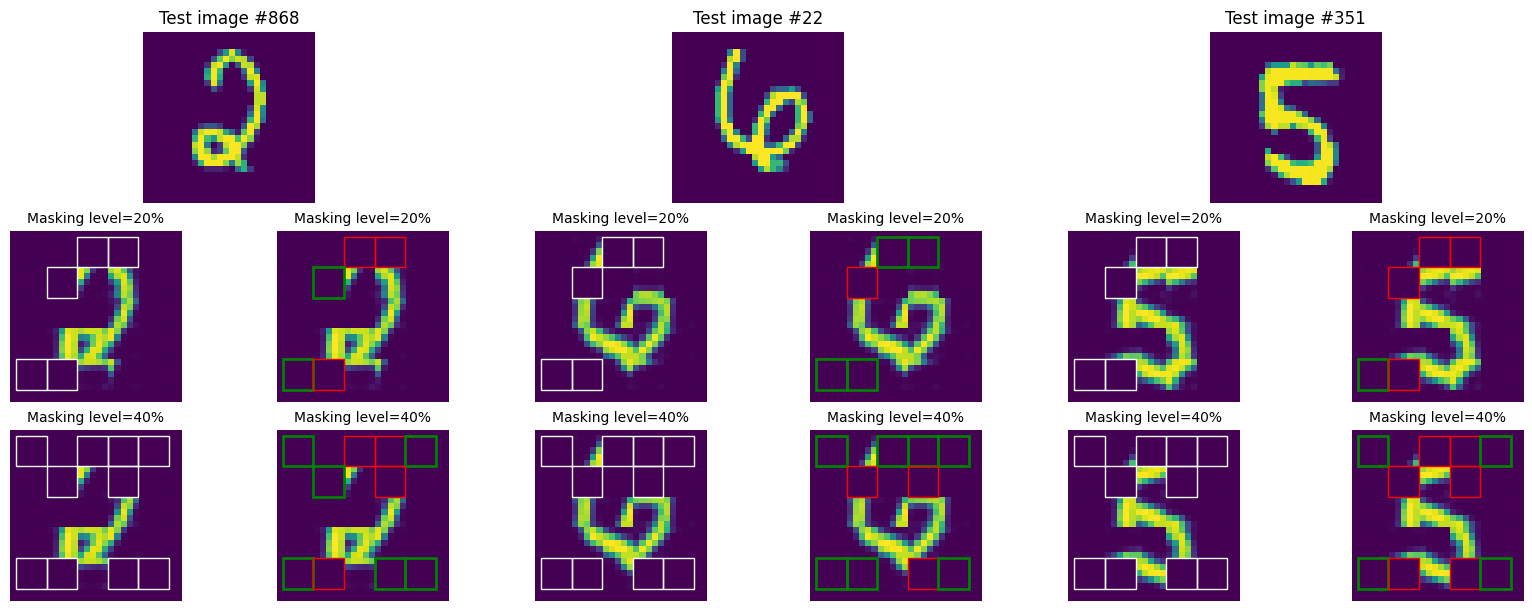

In [58]:
# @launchit.disable
df_example_samples = DC.df_test_samples.sample(3)
example_masks = generate_masks(len(df_example_samples.iloc[0].vocab_token_inds), HP.masking_levels)
fig = visualize_predictions(model, df_example_samples, HP.masking_levels, example_masks, is_test=True, device=CONFIG.cuda_device)

## Save

In [ ]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='main', replace=True)

## Save optuna trial result

In [36]:
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    if 'IS_PRUNED' in optuna_trial.user_attrs:
        raise optuna.exceptions.TrialPruned()

    if not METRICS_SUITE:
        LOG(f'Empty metrics suite. Cancelling model')
        optuna_multiprocessing.save_trial_result(0)
    else:
        match LAUNCH_GOAL.goal:
            case LaunchGoal.TRAIN_MODEL:
                last_loss_all = METRICS_SUITE['loss_all'][-1]
                optuna_multiprocessing.save_trial_result(last_loss_all)
                LOG(f'Train objective result={last_loss_all}')
            case _:
                assert False, f'Unsupported {LAUNCH_GOAL.goal=}'

# LaunchIt!

## TRAIN_MODEL

In [43]:
# @launchit.disable
launchit_t0 = time.time()

In [44]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN_MODEL.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=2
Creating /home/misha/dev/mine/neurovision/15_transformer/15_predict_01-launch2.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15_predict_01-launch2.ipynb"


## Optuna (model selection)

### Templates

In [45]:
# @launchit.disable
# @launchit.collect_2
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP = Hyperparameters()
            HP.random_seed = 42
            assert False
        case _:
            assert False, f'Unsupported {study_serial=}'            

### Unleash

In [ ]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.TRAIN_MODEL:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.TRAIN_MODEL
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 1
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
)
rop_tasks = [rop_task] * 1
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")